<a href="https://colab.research.google.com/github/marcinwolter/Varia/blob/main/unet_triangle_localization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# U-Net Triangle Localization Demo
Trains a small U-Net to detect triangles (but not circles) in synthetic images.

1.04.2026 M.W. with a help of claude.ai

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Polygon
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import cv2

np.random.seed(42)
tf.random.set_seed(42)

IMG_SIZE = 128
N_TRAIN = 800
N_VAL   = 100
EPOCHS  = 15
BATCH   = 16
print("Libraries loaded.")

2026-04-01 22:03:49.378849: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-01 22:03:49.454330: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Libraries loaded.


## 1. Data Generation

In [ ]:
def draw_triangle(img, mask, cx, cy, size, color):
    """Draw a filled triangle and mark its bounding region on the mask."""
    h = int(size * np.sqrt(3) / 2)
    pts = np.array([
        [cx,          cy - h // 2],
        [cx - size//2, cy + h // 2],
        [cx + size//2, cy + h // 2]
    ], dtype=np.int32)
    cv2.fillPoly(img,  [pts], color)
    cv2.fillPoly(mask, [pts], 1)   # mask = 1 where triangle


def draw_circle(img, cx, cy, radius, color):
    """Draw a filled circle (NOT added to mask)."""
    cv2.circle(img, (cx, cy), radius, color, -1)


def generate_image(img_size=IMG_SIZE, n_shapes=(2, 5)):
    img  = np.zeros((img_size, img_size, 3), dtype=np.float32)
    mask = np.zeros((img_size, img_size, 1), dtype=np.float32)

    n = np.random.randint(*n_shapes)
    for _ in range(n):
        size   = np.random.randint(12, 28)
        margin = size
        cx = np.random.randint(margin, img_size - margin)
        cy = np.random.randint(margin, img_size - margin)
        color = [np.random.uniform(0.4, 1.0) for _ in range(3)]

        if np.random.rand() > 0.5:
            draw_triangle(img, mask, cx, cy, size, color)
        else:
            draw_circle(img, cx, cy, size // 2, color)

    # light noise background
    img = np.clip(img + np.random.normal(0, 0.03, img.shape), 0, 1).astype(np.float32)
    return img, mask


def generate_dataset(n, img_size=IMG_SIZE):
    imgs, masks = [], []
    for _ in range(n):
        img, mask = generate_image(img_size)
        imgs.append(img)
        masks.append(mask)
    return np.array(imgs), np.array(masks)


X_train, Y_train = generate_dataset(N_TRAIN)
X_val,   Y_val   = generate_dataset(N_VAL)
print(f"Train: {X_train.shape}, Val: {X_val.shape}")

Train: (800, 128, 128, 3), Val: (100, 128, 128, 3)


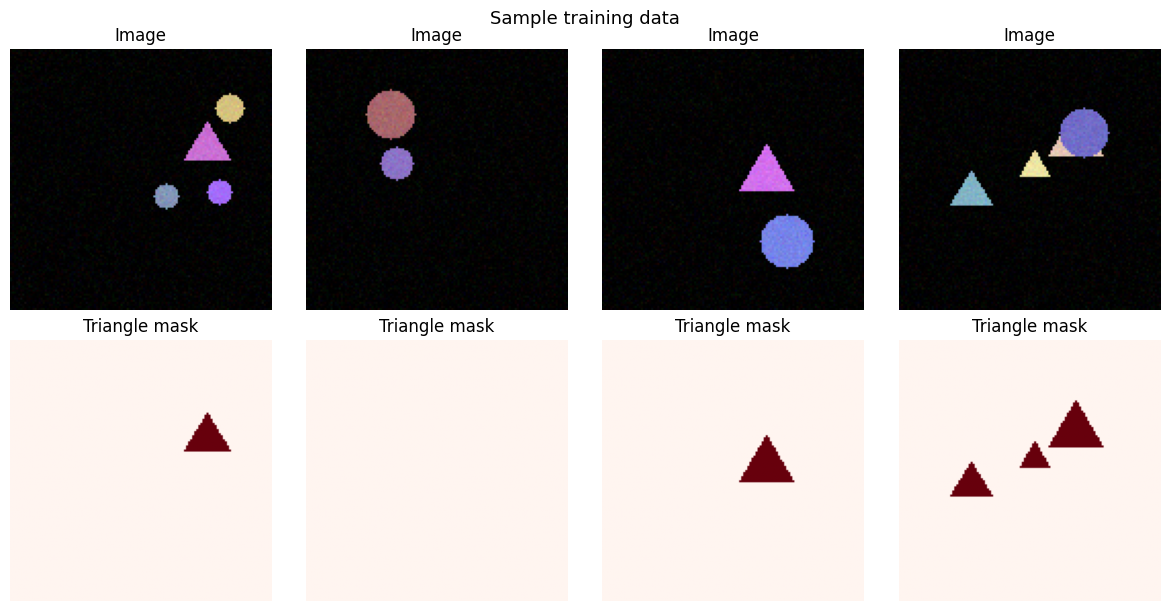

In [ ]:
# Quick peek at the training data
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(4):
    axes[0, i].imshow(X_train[i])
    axes[0, i].set_title("Image")
    axes[0, i].axis("off")
    axes[1, i].imshow(Y_train[i, :, :, 0], cmap="Reds")
    axes[1, i].set_title("Triangle mask")
    axes[1, i].axis("off")
plt.tight_layout()
plt.suptitle("Sample training data", y=1.01, fontsize=13)
plt.show()

## 2. Tiny U-Net Model

In [ ]:
def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    return x


def build_unet(img_size=IMG_SIZE, base_filters=16):
    inp = keras.Input((img_size, img_size, 3))

    # Encoder
    c1 = conv_block(inp, base_filters)          # 128
    p1 = layers.MaxPooling2D()(c1)              # 64
    c2 = conv_block(p1, base_filters * 2)       # 64
    p2 = layers.MaxPooling2D()(c2)              # 32

    # Bottleneck
    bn = conv_block(p2, base_filters * 4)       # 32

    # Decoder
    u3 = layers.UpSampling2D()(bn)              # 64
    u3 = layers.Concatenate()([u3, c2])
    c3 = conv_block(u3, base_filters * 2)

    u4 = layers.UpSampling2D()(c3)              # 128
    u4 = layers.Concatenate()([u4, c1])
    c4 = conv_block(u4, base_filters)

    out = layers.Conv2D(1, 1, activation="sigmoid")(c4)

    model = keras.Model(inp, out)
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy",
                 tf.keras.metrics.MeanIoU(num_classes=2, name="iou")]
    )
    return model


model = build_unet()
model.summary()

I0000 00:00:1775073840.362041  119490 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 705 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:07.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        448 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      2,320 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │      9,248 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │     36,928 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 64,    │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 96)               │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 64, 64,    │     27,680 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 64, 64,    │      9,248 │ conv2d_6[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 128, 128,  │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128, 128,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 48)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 128, 128,  │      6,928 │ concatenate_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 128, 128,  │      2,320 │ conv2d_8[0][0]  

 Total params: 118,273 (462.00 KB)

 Trainable params: 118,273 (462.00 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Training

In [ ]:
callbacks = [
    keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5, verbose=1),
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, verbose=1)
]

history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=EPOCHS,
    batch_size=BATCH,
    callbacks=callbacks
)

Epoch 1/15


2026-04-01 22:04:05.654153: I external/local_xla/xla/service/service.cc:163] XLA service 0x7fe840006f50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-01 22:04:05.654181: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2026-04-01 22:04:05.778036: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-01 22:04:06.428202: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90300
2026-04-01 22:04:06.812951: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[16,16,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,3,128,128]{3,2,1,0}, f32[16,3,3,3]{3,2,1,0}, f32[16]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudn

 5/50 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9851 - iou: 0.4932 - loss: 0.6502

I0000 00:00:1775073851.916066  119829 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9839 - iou: 0.4921 - loss: 0.3073

2026-04-01 22:04:15.258893: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[16,16,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,3,128,128]{3,2,1,0}, f32[16,3,3,3]{3,2,1,0}, f32[16]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-04-01 22:04:15.384184: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[16,16,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,16,128,128]{3,2,1,0}, f32[16,16,3,3]{3,2,1,0}, f32[16]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_targe

2026-04-01 22:04:17.092563: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[4,64,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[4,32,32,32]{3,2,1,0}, f32[64,32,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-04-01 22:04:17.132612: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[4,64,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[4,64,32,32]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn

50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 120ms/step - accuracy: 0.9836 - iou: 0.4918 - loss: 0.1404 - val_accuracy: 0.9829 - val_iou: 0.4915 - val_loss: 0.0317 - learning_rate: 0.0010
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.9837 - iou: 0.4918 - loss: 0.0279 - val_accuracy: 0.9829 - val_iou: 0.4915 - val_loss: 0.0253 - learning_rate: 0.0010
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.9919 - iou: 0.4918 - loss: 0.0173 - val_accuracy: 0.9980 - val_iou: 0.4915 - val_loss: 0.0118 - learning_rate: 0.0010
Epoch 4/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.9980 - iou: 0.4918 - loss: 0.0073 - val_accuracy: 0.9984 - val_iou: 0.4915 - val_loss: 0.0050 - learning_rate: 0.0010
Epoch 5/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.9986 - iou: 0.4918 - loss: 0.0046 - val_accuracy: 0.9986 - val_iou: 0.4915 - val_loss: 0.0042 - learning_rate: 0.0010
Epoch 6/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9988 - iou: 0.4918 - loss: 0.

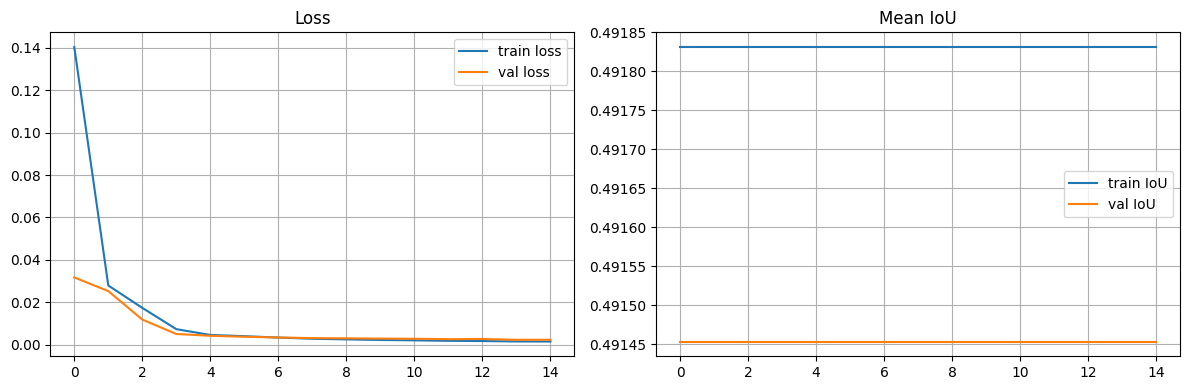

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"],     label="train loss")
axes[0].plot(history.history["val_loss"], label="val loss")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history["iou"],     label="train IoU")
axes[1].plot(history.history["val_iou"], label="val IoU")
axes[1].set_title("Mean IoU"); axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.show()

## 4. Inference & Visualization

2026-04-01 22:04:44.843133: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[8,16,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,3,128,128]{3,2,1,0}, f32[16,3,3,3]{3,2,1,0}, f32[16]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-04-01 22:04:44.917327: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=0} for conv (f32[8,16,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,16,128,128]{3,2,1,0}, f32[16,16,3,3]{3,2,1,0}, f32[16]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="_

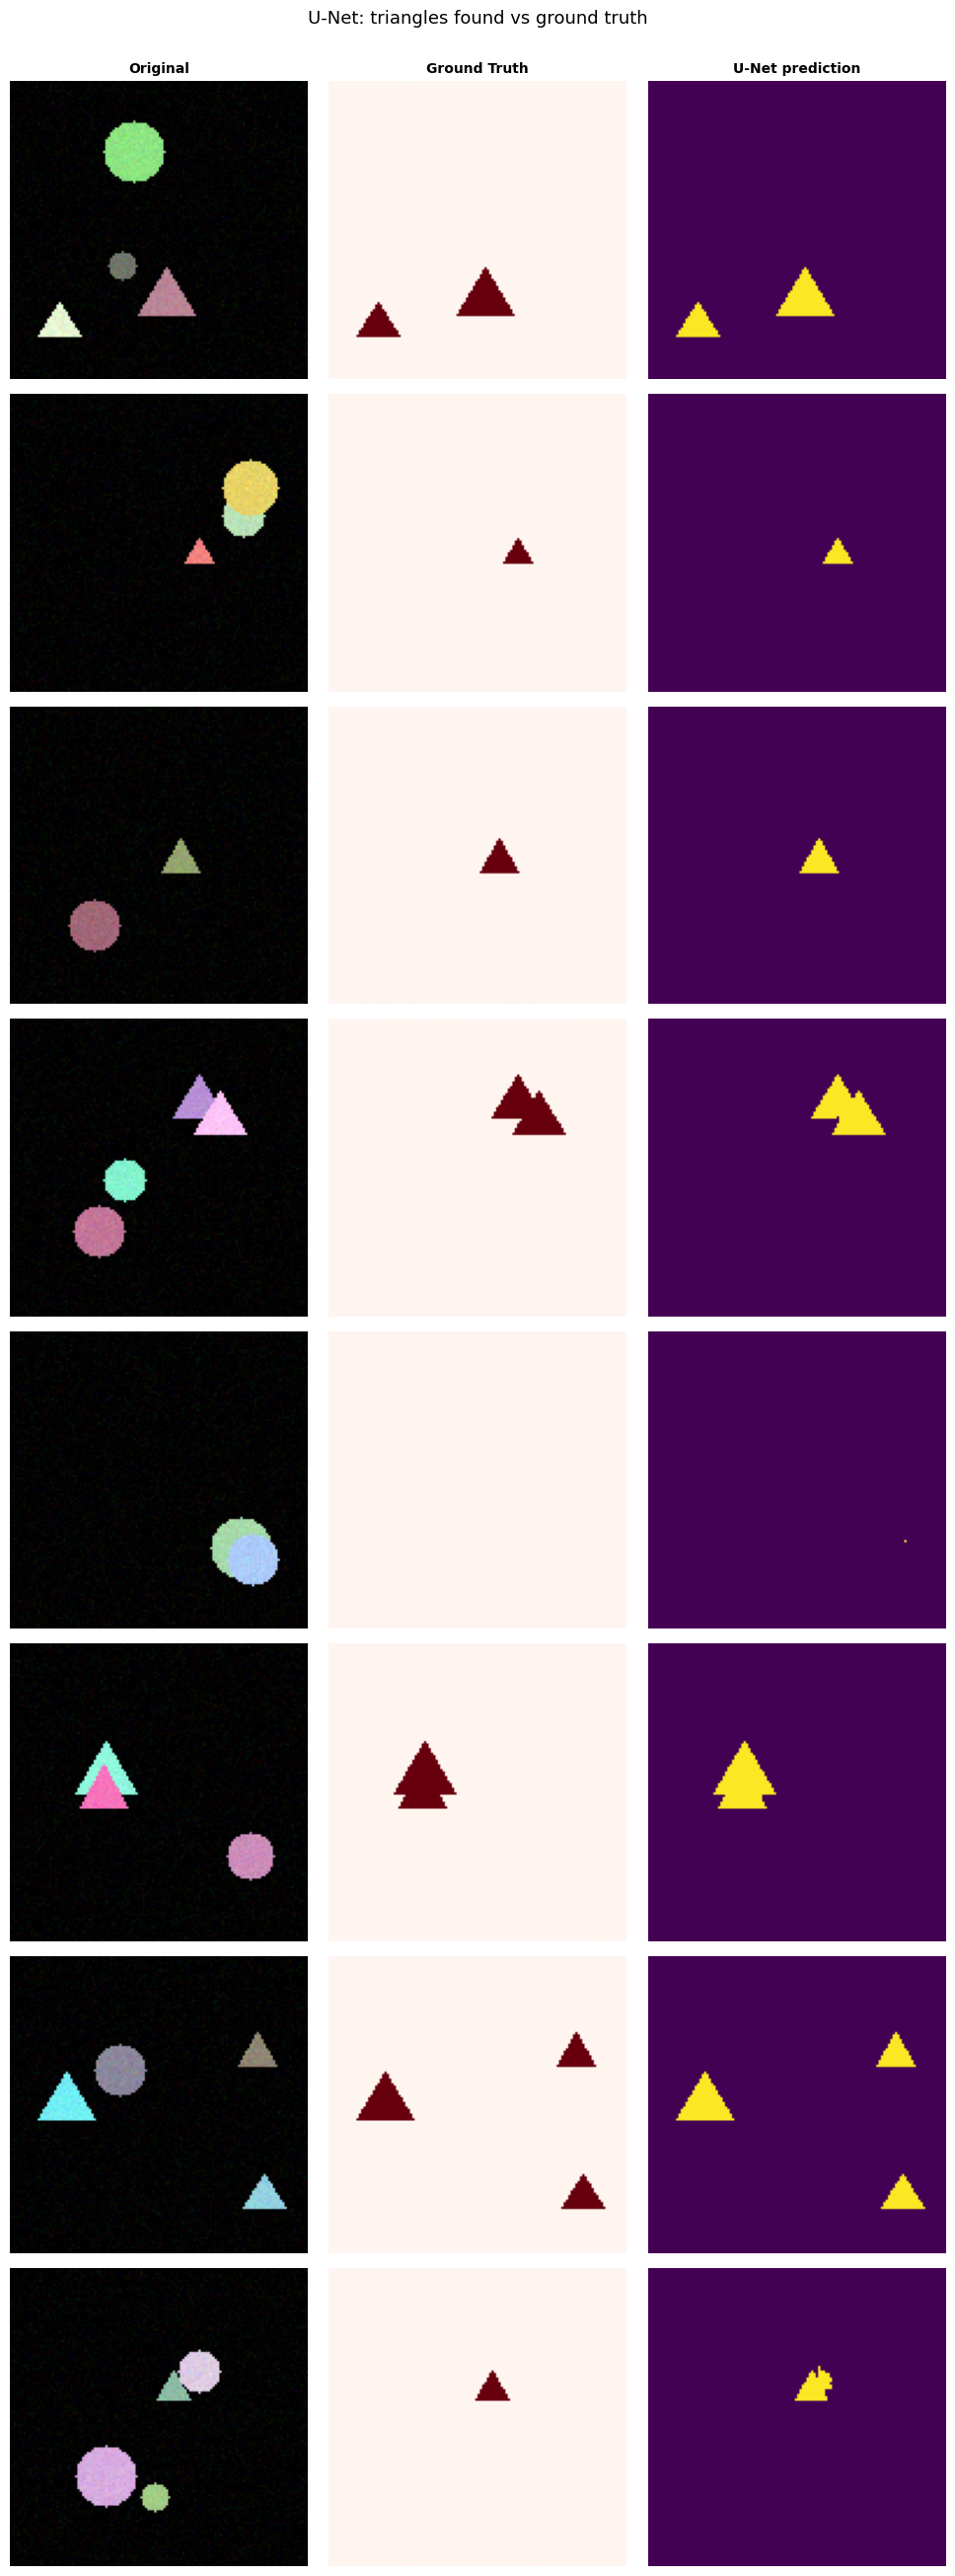

In [ ]:
# Generate fresh test images
X_test, Y_test = generate_dataset(8)
preds = model.predict(X_test, verbose=0)   # shape (8, 128, 128, 1)

THRESHOLD = 0.4

fig, axes = plt.subplots(8, 3, figsize=(10, 26))
col_titles = ["Original", "Ground Truth", "U-Net prediction"]

for i in range(8):
    img   = X_test[i]
    gt    = Y_test[i, :, :, 0]
    pred  = preds[i, :, :, 0]

    # --- overlay predicted mask as light red ---
    overlay = img.copy()
    heat = (pred > THRESHOLD).astype(np.float32)
    # blend: push R channel up, suppress G and B slightly
    overlay[:, :, 0] = np.clip(overlay[:, :, 0] + 0.55 * heat, 0, 1)
    #overlay[:, :, 0] = np.clip(overlay[:, :, 0] , 0, 1)
    overlay[:, :, 1] = np.clip(overlay[:, :, 1] - 0.25 * heat, 0, 1)
    overlay[:, :, 2] = np.clip(overlay[:, :, 2] - 0.25 * heat, 0, 1)

    axes[i, 0].imshow(img);     axes[i, 0].axis("off")
    axes[i, 1].imshow(gt, cmap="Reds", vmin=0, vmax=1); axes[i, 1].axis("off")
    #axes[i, 2].imshow(overlay); axes[i, 2].axis("off")
    axes[i, 2].imshow(heat); axes[i, 2].axis("off")

    if i == 0:
        for j, t in enumerate(col_titles):
            axes[0, j].set_title(t, fontsize=10, fontweight="bold")

plt.suptitle("U-Net: triangles found vs ground truth", fontsize=13, y=1.002)
plt.tight_layout()
plt.show()